In [18]:
# Chapter 2: Supervised Learning

In [19]:
# Overfitting and Underfitting

# Building a model that is too complex for the amount of information we have - overfit
# Overfitting occurs when you fit a model too closely to the particularities of the
# training set and obtain a model that works well on the trainig set but is not able
# to generalize to new data

# Choosing to simple a model is called - underfitting
# Might not able to capture all the aspects of and variability in the data and 
# your model will do badly even on the training set

In [20]:
# The more complex we allow our model to be, the better we will be able to predict on
# the training data. However, if our model becomes too complex, we start focusing too
# much on each individual data poing in our training set, and the model will not 
# generalize well to new data

In [21]:
# There is a sweet spot in between that will yield the best generalization performance.
# This is the model we want to find.

In [22]:
# Relation of Model Complexity to Dataset Size
# The larger variety of data points your dataset contaings, the more complex a model
# you can user without overfitting.
# Usually, collecting more data points will yield more variety, so larger datasets allow
# building more complex models

In [23]:
# Supervised Machine Learning Algorithms

In [24]:
import mglearn
import matplotlib.pyplot as plt

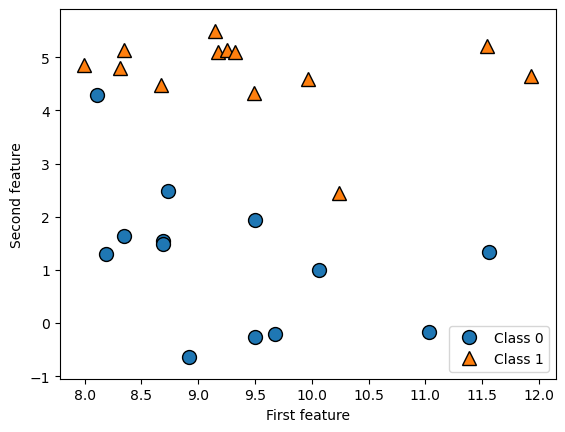

X.shape: (26, 2)


In [25]:
# synthetic two-class classification dataset is the forge dataset, which has two features

# generate dataset
X, y = mglearn.datasets.make_forge()
# plot dataset
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()
print("X.shape: {}".format(X.shape))

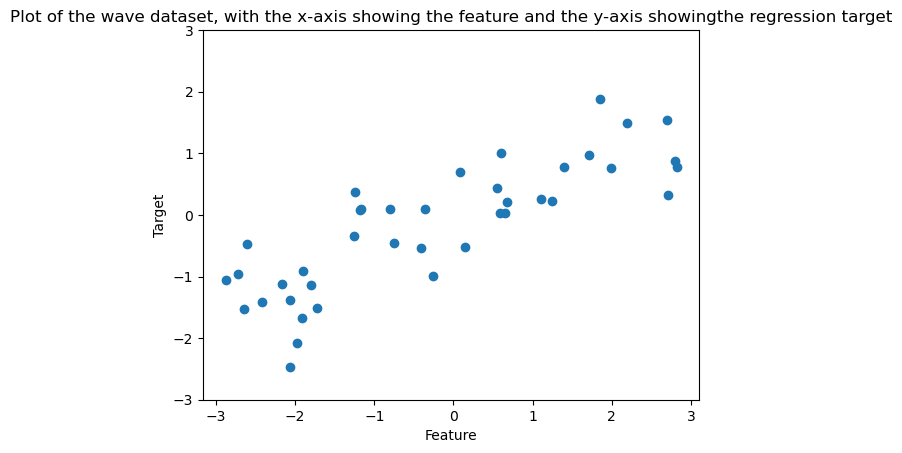

In [26]:
# synthetic wave dataset to illustrate regression algorithms

X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Plot of the wave dataset, with the x-axis showing the feature and the y-axis showingthe regression target")
plt.show()

In [27]:
# datasets with few featrures - low-dimensional datasets
# with many features - high-dimensial datasets

In [28]:
# Wisconsin Breast Cancer dataset
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print("cancer.keys(): \n{}".format(cancer.keys()))

cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [29]:
# in scikit-learn datasets have usually Bunch-objects.
# They behave like dictionaries with the added benefit that you can access values using a dot
print("Shape of cancer data: {}".format(cancer.data.shape))

Shape of cancer data: (569, 30)


In [30]:
import numpy as np
print("Sample counts per class: \n{}".format(
    {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))

Sample counts per class: 
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [31]:
print("Feature names: \n{}".format(cancer.feature_names))

Feature names: 
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [32]:
# Boston Housing dataset
#from sklearn.datasets import load_boston
#print("Data shape: {}".format(boston.data.shape))

In [33]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
print("Data shape: {}".format(data.shape))

Data shape: (506, 13)


In [34]:
X, y = mglearn.datasets.load_extended_boston()
print("X.shape: {}".format(X.shape))

X.shape: (506, 104)


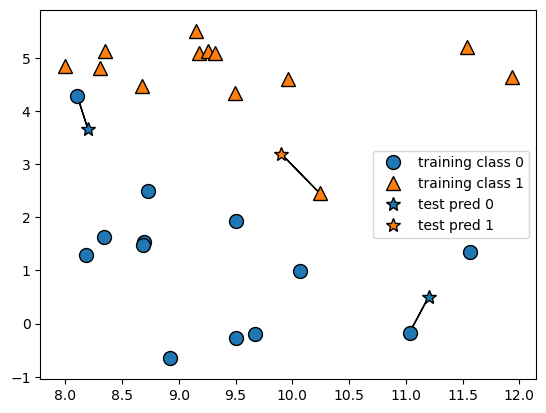

In [35]:
# Predictions made by the one-nearest neighbor model on the forge dataset
mglearn.plots.plot_knn_classification(n_neighbors=1)

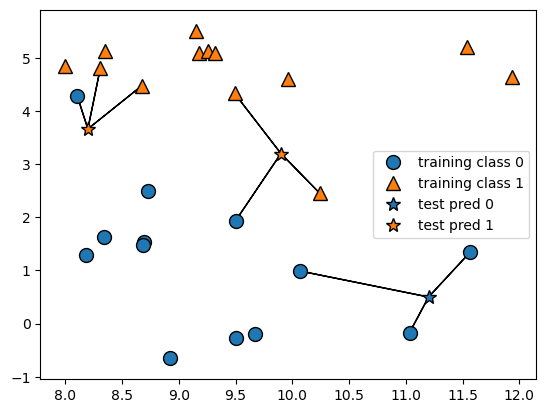

In [36]:
# Predictions made by the three-nearest-neighbors model on the forge dataset
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [37]:
# k-nearest neighbors algorithm using scikitlearn
# First, we split our data into a training and a test set so we can evaluate general‐
# ization performance

from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [38]:
# Next, we import and instantiate the class. This is when we can set parameters, like the
# number of neighbors to use

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

In [39]:
# Now we fit the classifier using the training set
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [40]:
# To make predictions on the test data, we call the predict method. For each data point
# in the test set, this computes its nearest neighbors in the training set and finds the
# most common class amongst these:

print("Test set predictions: {}".format(clf.predict(X_test)))

Test set predictions: [1 0 1 0 1 0 0]


In [41]:
# To evaluate how well our model generalizes, we can call the score method with the
# test data together with the test labels:

print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Test set accuracy: 0.86


In [42]:
# We see that our model is about 86% accurate, meaning the model predicted the class
# correctly for 86% of the samples in the test dataset

In [43]:
# Analyzing KNeighborsClassifier

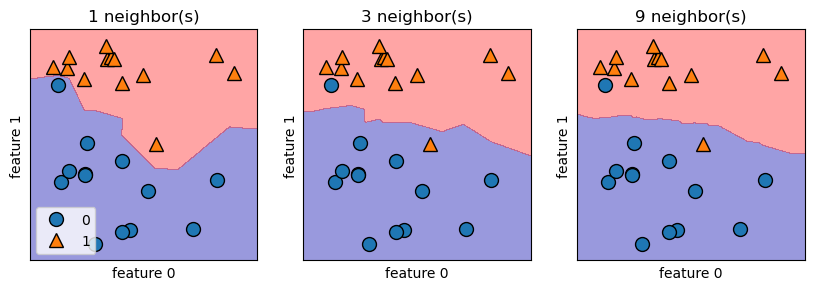

In [44]:
# For two-dimensional datasets, we can also illustrate the prediction for all possible test
# points in the xy-plane. We color the plane according to the class that would be
# assigned to a point in this region. This lets us view the decision boundary, which is the
# divide between where the algorithm assigns class 0 versus where it assigns class 1.

# The following code produces the visualizations of the decision boundaries for one,
# three, and nine neighbors

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    # the fit method returns the object self, so we can instantiate
    # and fit in one line
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

# Decision boundaries created by the nearest neighbors model for different values of
# n_neighbors

In [45]:
# Let’s investigate whether we can confirm the connection between model complexity
# and generalization
# We will do this on the real-world Breast
# Cancer dataset

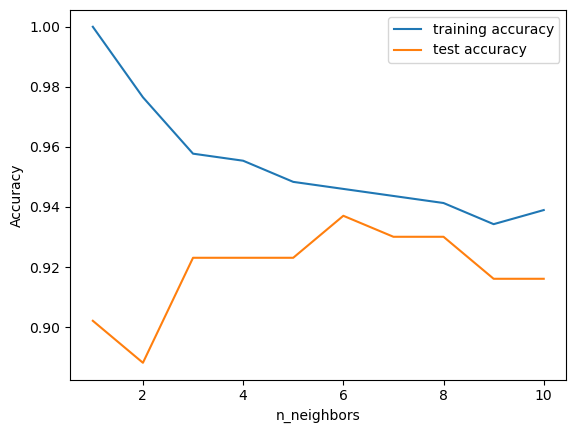

In [46]:
# We begin by splitting the dataset into a training and a test set. Then
# we evaluate training and test set performance with different numbers of neighbors.

from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    #record generalization accuracy
    test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

# Comparison of training and test accuracy as a function of n_neighbors

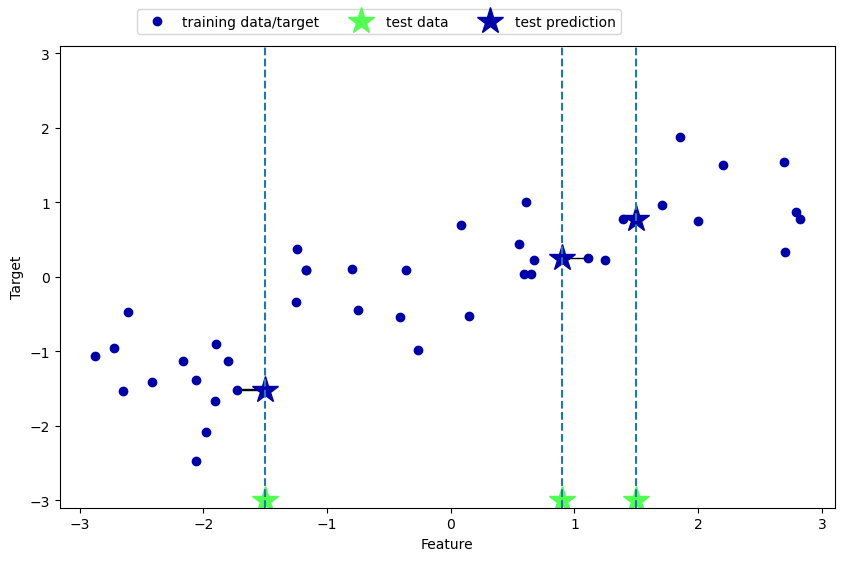

In [47]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

# Predictions made by one-nearest-neighbor regression on the wave dataset

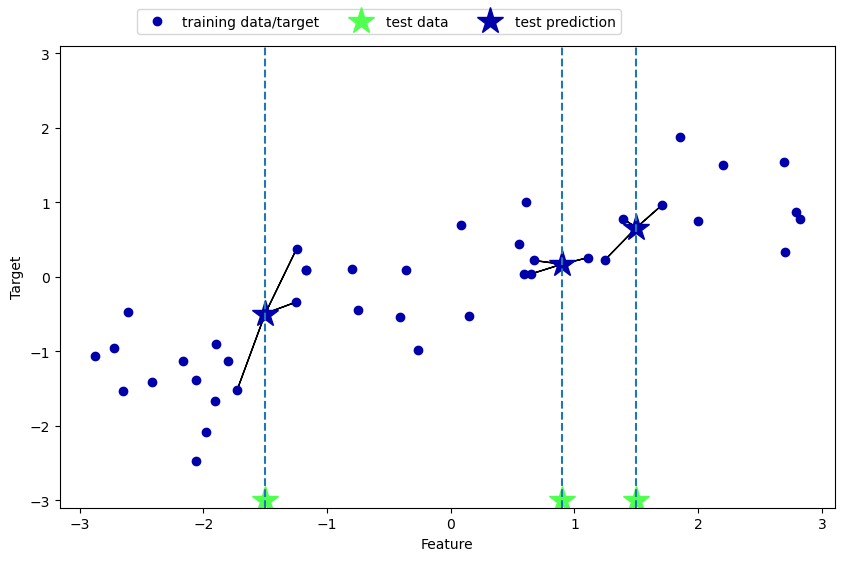

In [48]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

# Predictions made by three-nearest-neighbors regression on the wave dataset

In [49]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)

# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# instantiate the model and set thge number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training daata and training targets
reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [50]:
# Now we can make predictions on the test set:
print("Test set predictions:\n{}".format(reg.predict(X_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [51]:
# We can also evaluate the model using the score method, which for regressors returns
# the R^^2 score. The R^^2 score, also known as the coefficient of determination, is a meas‐
# ure of goodness of a prediction for a regression model, and yields a score between 0
# and 1. A value of 1 corresponds to a perfect prediction, and a value of 0 corresponds
# to a constant model that just predicts the mean of the training set responses, y_train:

print("Test set R^2: {:.2f}".format(reg.score(X_test, y_test)))

Test set R^2: 0.83


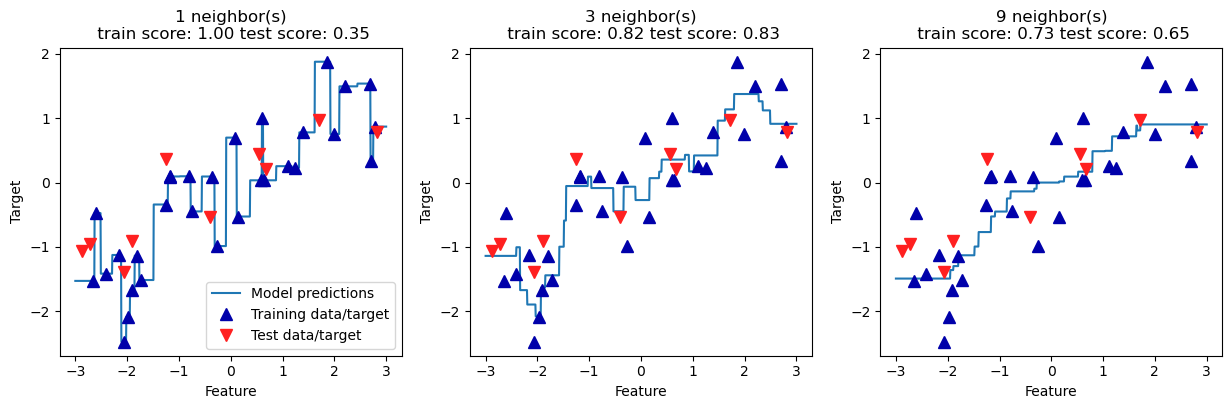

In [52]:
# Analyzing KNeighborsRegressor
# For our one-dimensional dataset, we can see what the predictions look like for all
# possible feature values. To do this, we create a test dataset consisting of
# many points on the line

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# create 1,000 data points, evenly spaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
    # make predictions using 1, 3 or 9 neighbors
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
                "Test data/target"], loc="best")

In [53]:
# Strenghts, weaknesses and parameters

# There are two important parameters to the KNeighbors classifier: the number
# of the neighbors and how you measure distance between data points. In practise,
# using a small number of neighbors like three or five often works well, but you
# should certainly adjust this parameter. Choosing the right distance measure is
# somewhat beyond the scope of this book. By default, Euclidean distance is used,
# which works well in many settings.

In [54]:
# One of the strengths of k-NN is that the model is very easy to understand, and often
# gives reasonable performance without a lot of adjustments. Using this algorithm is a
# good baseline method to try before considering more advanced techniques.
# Building the nearest neighbors model is usually very fast, but when your training
# set is very large (either in number of features or in number of samples) prediction
# can be slow. When using the k-NN algorithm, it's important to preprocess your data.
# This approach often does not perform well on datasets with many features (hundreds
# or more), and it does particularly badly with datasets where most features are 0
# most of the time (so-called sparse datasets).

In [55]:
# So, while the nearest k-neighbors algorithm is easy to understand, it is not often
# used in practice, due to prediction being slow and its inability to handle many features

In [56]:
# LINEAR MODELS

In [57]:
# linear models are a class of models that are widely used in practice and have been
# studied extensively in the last few decades, with roots going back over a hundred
# years. Linear models make a prediction using a linear function of the input features,
# which we will explain shortly.

In [58]:
# Linear models for regression
# for regression, the general prediction formula for a linear model looks as follows:
# y = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b
# Here, x[0] to x[p] denotes the features (in this example, the number of features is p)
# of a single data point, w and b are parameters of the model that are learned, and y
# is the prediction the model makes. For a dataset with a single feature, this is:
# y = w[0] * x[0] + b,
# which is the equation for a line. Here, w[0] is the slope and b is the y-axis offset
# for more features, w contains the slopes along each feature axis.
# Alternatively, you can think of the predicted response as being a weighted sum of 
# the input features, with weights (which can be negative) given by the entries of w.

w[0]: 0.393906  b: -0.031804


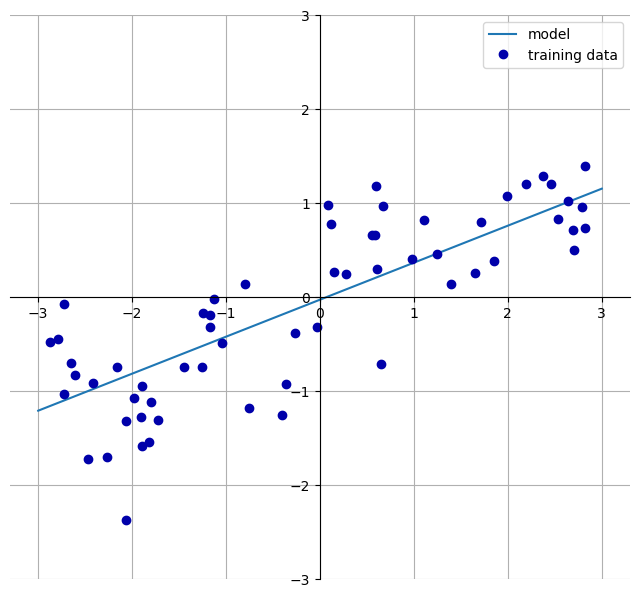

In [59]:
# Prediction of a linear model on the wave dataset
mglearn.plots.plot_linear_regression_wave()

In [60]:
# Linear models for regression can be characterized as regression models for which
# the prediction is a line for a single feature, a plane when using two features, or
# a hyper-plane in higher dimensions (that is, when using more features).
# // plane - плоскость

In [61]:
# Looking at one-dimenstional data gives a somewhat skewed perspective.
# For datasets with many features, lines models can be very powerful.
# In particular, if you have more features than training data points, any target y
# can be prefectly modeled (on the training set) as a linear function

In [62]:
# There are many different linear models for regression. The difference between these
# models lies in how the model parameters w and b are learned from the training data,
# and how model complexity can be controlled. We will now take a look at the most
# popular linear models for regression.

In [63]:
# Linear regression (aka ordinary least squares)

# Linear regression, or ordinary least squares (OLS) // Метод наименьших квадратов
# is the simplest and most classic linear method for regression. Linear regression
# finds the parameters w and b that minimize the mean squared error between 
# predictions and the true regression targets, y, on the training set.
# The mean squared error is the sum of the squared differences between the
# predictions and the true values. Linear regression has no parameters, which is a 
# benefit, but it also has no way to control model complexity.

In [66]:
from sklearn.linear_model import LinearRegression

X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

In [69]:
# The "slope" parameters (w), also called weights or coefficients, are stored in the
# coef_ attribute, while the offset or intercept (b) is stored in the
# intercept_ attribute:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

# Underscore at the end of coef_ and intercept_ - scikit-learn always stores anything
# that is derived from the training data in attributes that end with a trailing
# underscore. That is to separate them from parameters that are set by the user.

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [70]:
# intercept_ - always a single float number
# coef_ - numpy array with one entry per input feature
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


In [73]:
# For this one-dimensional dataset, there is little danger of overfitting, as the
# model is very simple (or restricted). However, with higher-dimensional datasets
# (meaning datasets with a large number of features), liner models become more powerful
# and there is a higher chance of overfitting.

In [74]:
# Example of Linear Regression with Boston Housing dataset
X, y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

In [76]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))
#Train - overfit

Training set score: 0.95
Test set score: 0.61


In [77]:
# We should try to find a model that allow us to control complexity
# One of the most commonly used alternatives to standart linear regression is
# ridge regression

In [78]:
# RIDGE REGRESSION

In [79]:
# In ridge regression the coefficients (w) are chosen not only so that they predict well
# on the training data, but also to fit and additional constraint. We also ant the
# magnitude of coefficients to be as small as possible; in other words; all entries of
# w should be close to zero. Inuitively, this means each feature should have as little
# effect on the outcomee as possible (which translates to having a small slope), while
# still predicting wel. This constraint is an example of what is called
# regularization. Regularization means explicitly restricting a model to avoid
# overfitting. The particular king used by ridge regression is known as L2 regularization.


In [81]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.89
Test set score: 0.75


In [82]:
# Ridge is a more restricted model, so we are less likely to overfit.
# A less complex model means worse performance on the training set, but better
# generalization.

In [84]:
# How much importance the model places on simplicity versus training set performance
# can be specified by the user, using the alpha parameter.
# There is no reasin why default alpha = 1 will give us the best trade-off.
# The optimum setting of alpha depends on the particular dataset we are using.
# Increasing alpha forces coefficients to move more toward zero, which decreases
# training set performance but might help generalization.

ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set score: 0.79
Test set score: 0.64


In [96]:
# For very small values of alpha, coefficients are barely restricted at all,
# and we end up with a model that resembles LinearRegression

ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge01.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.77


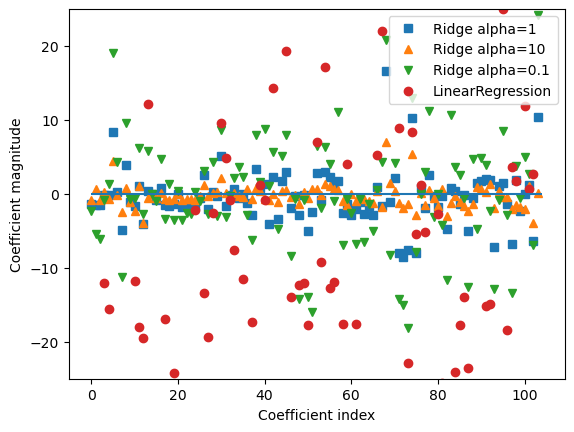

In [97]:
# A higher alpha means a more restricted model, so we expect the entries of coef_ to
# have smaller magnitude for a high value of alpha than for a low value of alpha.

plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()

# Comparing coefficient magnitudes for ridge regression with different values of alpha
# and linear regression

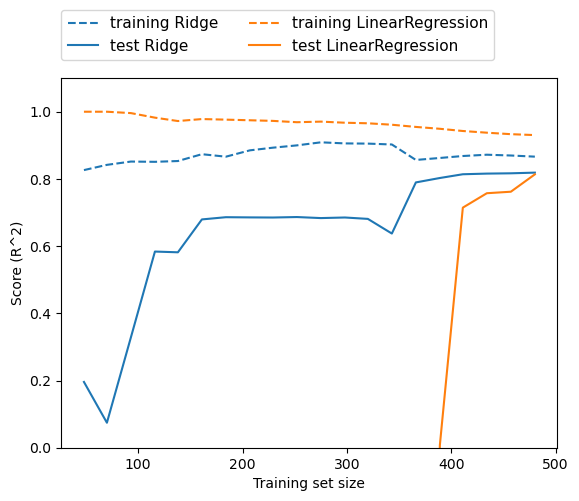

In [99]:
# Another way to understand the influence of regularization is to fix a value of alpha
# but vary the amount of training data available.
mglearn.plots.plot_ridge_n_samples()

# Learning curves for ridge regression and linear regression on the Boston Housing
# dataset

In [100]:
# As one would expect, the training score is higher than the test score for all dataset
# sizes, for both ridge and linear regression. Because ridge is regularized, the trainng
# score of ridge is lower than the training score for linear regression across the board.
# However, the test score for ridge is better, particularly for small subsets of the data
# For less than 400 data points, linear regression is not able to learn anything. As more
# and more data becomes available to the model, both models improve, and linear regression
# cathces up with ridge in the end. The lesson here is that with enough trainings data,
# regularization becomes less important, and given enough data, ridge and linear regression
# will have the same performance (the fact that this happens here when using the full dataset
# is just by chance). Another interesting aspect is the decrease in training performance
# for linear regression. If more data is added, it becomes harder for a model to overfit,
# or memorize the data.